# Analiza podatkov

### Tukaj bomo analizirali podatke o namiznih igrah s spletne strani  od BoardGameGeek.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Lestvica najboljše rangiranih žanrov.

In [2]:
igre = pd.read_csv("podatki.csv", index_col="id")
najboljsi_zanr = igre.groupby("žanr")["rating"].mean().sort_values(ascending=False)
najboljsi_zanr

žanr
Strategy        7.492164
Customizable    7.468000
War             7.454054
Thematic        7.373239
Abstract        6.971667
Family          6.970070
Party           6.797391
Children's      5.700000
Name: rating, dtype: float64

Sortirano število iger na leto.

In [3]:
igre_v_letu = igre.groupby("leto izdaje").size().sort_values(ascending=False).head(10)
igre_v_letu

leto izdaje
2017    90
2015    85
2016    84
2018    82
2019    82
2020    62
2021    61
2022    59
2014    58
2012    54
dtype: int64

Najbolj polularne igre, izračunano je z zmnožkom ratinga in številom ratingov.

In [4]:
igre["popularnost"] = igre["rating"] * igre["število rating-ov"]
igre.sort_values("popularnost", ascending=False).head(10)["ime"]

id
822             Carcassonne
30549              Pandemic
13                    Catan
167791    Terraforming Mars
266192             Wingspan
173346       7 Wonders Duel
68448             7 Wonders
230802                 Azul
178900            Codenames
169786               Scythe
Name: ime, dtype: str

Katere igre se res ne splača učiti, ker je hkrati prezahtevna in predolga?

In [5]:
igre["ali se splača učiti"] = igre["zahtevnost /5"] * igre["najdaljši čas"]
igre.sort_values("ali se splača učiti", ascending=False).head(10)
#večja kot je vrednost, bolj se NE splača učiti igre

,ime,rank,žanr,rating,število rating-ov,leto izdaje,najmanjša starost,zahtevnost /5,najmanj igralcev,največ igralcev,najkrajši čas,najdaljši čas,najnižja cena ($),popularnost,ali se splača učiti
id,,,,,,,,,,,,,,,
255984,Sleeping Gods,75.0,Thematic,8.1,16000,2021,13.0,3.26,1.0,3.0,60.0,1200.0,40.43,129600.0,3912.0
180263,The 7th Continent,167.0,Thematic,7.7,23000,2017,14.0,2.90,1.0,2.0,5.0,1000.0,32.99,177100.0,2900.0
233078,Twilight Imperium: Fourth Edition,7.0,Thematic,8.6,29000,2017,14.0,4.36,3.0,6.0,240.0,480.0,9.97,249400.0,2092.8
91,Paths of Glory,265.0,War,8.1,5700,1999,14.0,3.86,2.0,2.0,480.0,480.0,50.00,46170.0,1852.8
421,1830: Railways & Robber Barons,314.0,Strategy,7.9,6000,1986,14.0,4.17,3.0,6.0,180.0,360.0,29.99,47400.0,1501.2
192836,The Colonists,752.0,Strategy,7.5,4500,2016,12.0,4.06,1.0,3.0,30.0,360.0,35.00,33750.0,1461.6
1513,The Republic of Rome,844.0,Strategy,7.5,4300,1990,14.0,4.37,4.0,6.0,300.0,300.0,235.00,32250.0,1311.0
71,Civilization,538.0,Strategy,7.5,7700,1980,12.0,3.64,4.0,7.0,360.0,360.0,9.43,57750.0,1310.4
483,Diplomacy,887.0,War,7.0,14000,1959,12.0,3.32,6.0,7.0,360.0,360.0,5.00,98000.0,1195.2


## Grafi

(0.0, 50.0)

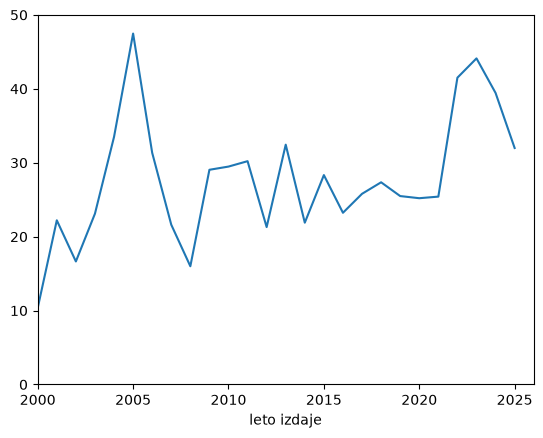

In [6]:
cenovni_ratingi = igre.groupby("leto izdaje")["najnižja cena ($)"].mean()
ax = cenovni_ratingi.plot()
ax.set_xlim(2000, 2026)
ax.set_ylim(0, 50)

Graf povprečnih cen iger v vsakem letu. Kot vidimo je trend naraščajoč, najbrž zaradi inflacije.

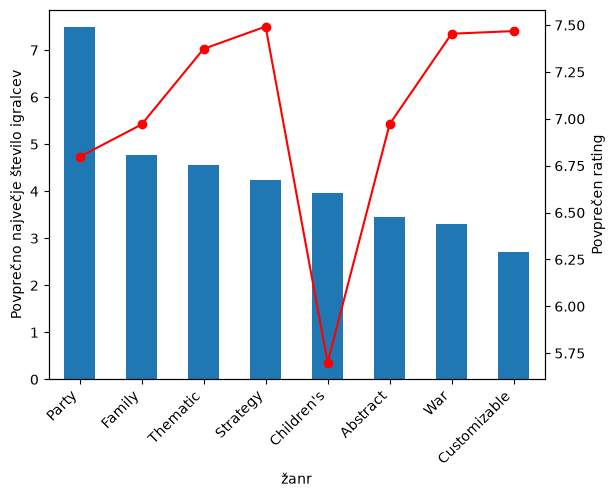

In [7]:
trajanje_zanri = igre.groupby("žanr")[["največ igralcev", "rating"]].mean().sort_values("največ igralcev", ascending=False)
ax = trajanje_zanri["največ igralcev"].plot.bar()
trajanje_zanri["rating"].plot(ax=ax, secondary_y=True, color="red", marker="o")
ax.set_ylabel("Povprečno največje število igralcev")
ax.right_ax.set_ylabel("Povprečen rating")
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

Graf, ki s stolpci prikazuje povprečno največje število igralcev primerno za igro za določen žanr.
Hkrati še rdeča črta prikazuje povprečen rating vsakega žanra.
Vidimo, da ima jo "Party" igre običajno največje možno število igralcev.

Text(0, 0.5, 'Rating')

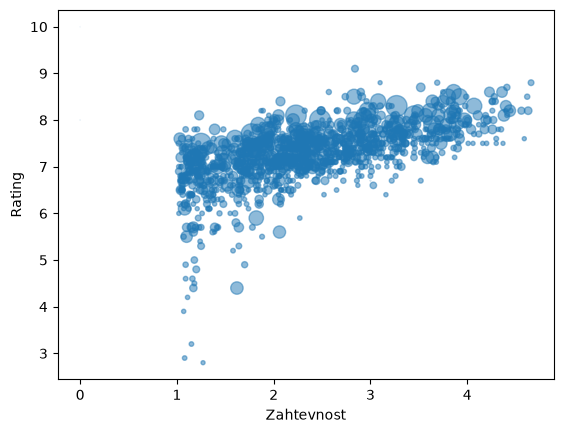

In [8]:
ax = igre.plot.scatter(
    x="zahtevnost /5",
    y="rating",
    s=igre["število rating-ov"] / 500, #debelina kroga
    alpha=0.5 #prosojnost
)

ax.set_xlabel("Zahtevnost")
ax.set_ylabel("Rating")

Ta graf prikazuje tri lastnosti; na x osi je zahtevnost igre do 5, na y osi je rating igre, nazadnje pa še
debelina kroga predstavlja število ratingov.
Vidimo, da imajo zahtevnejše igre običajno večji rating.

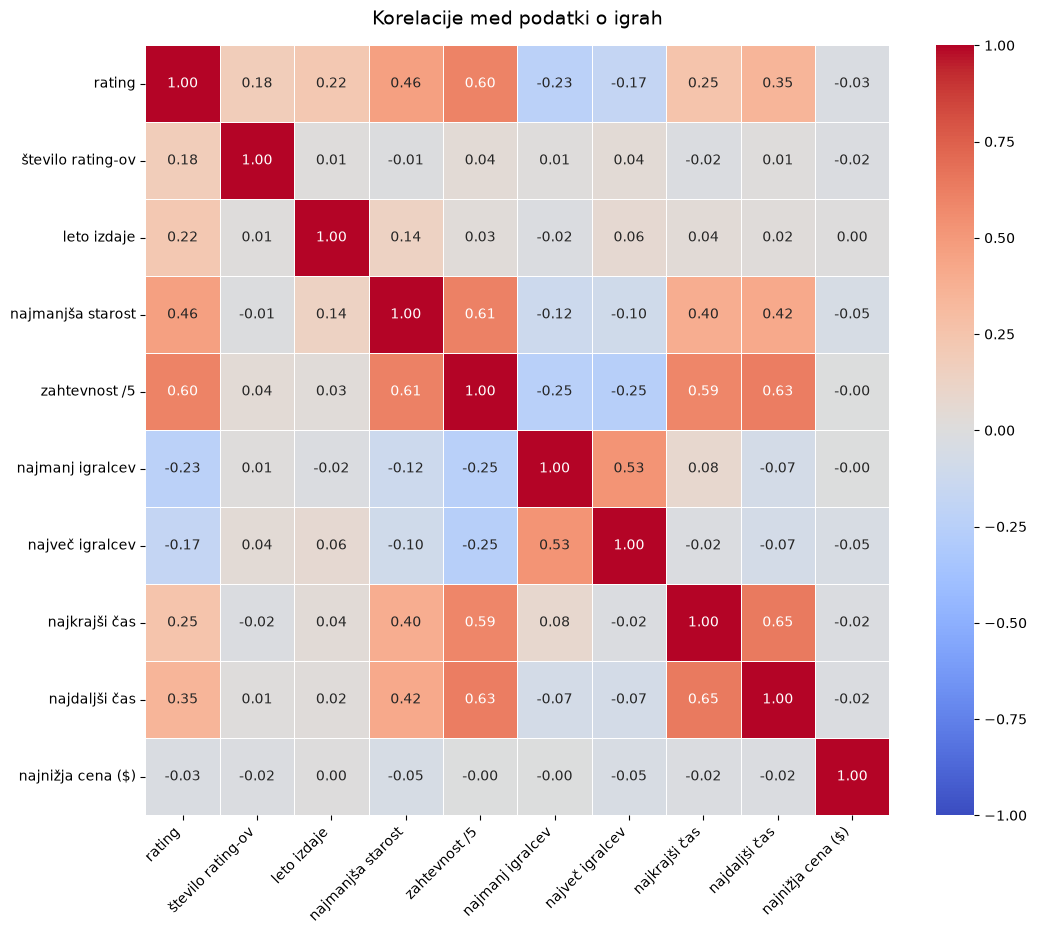

In [9]:
podatki = igre[
    [
        "rating",
        "število rating-ov",
        "leto izdaje",
        "najmanjša starost",
        "zahtevnost /5",
        "najmanj igralcev",
        "največ igralcev",
        "najkrajši čas",
        "najdaljši čas",
        "najnižja cena ($)"
    ]
]

podatki = podatki.dropna() #odstrani vrstice kjer manjkajo podatki
korelacije = podatki.corr()

plt.figure(figsize=(12, 10)) #dimenzija okna

sns.heatmap(
    korelacije,
    annot=True, #keoficienti korelacije
    cmap="coolwarm", #barve
    vmin=-1, #razpon vrednosti
    vmax=1,
    linewidths=0.5, 
    fmt=".2f" #2 decimalki
)

plt.title("Korelacije med podatki o igrah", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.show()

To je korelacijska matrika vseh številčnih podatkov, ki sem jih zbral. Koeficient 1 predstavlja največjo korelacijo med
dvema podatkoma, medtem ko koeficient -1 predstavlja nobene korelacije med podatkoma.
Kot vidimo sta na primer dolg čas igranja in zahtevnost igre tesno povezana, kar ima kar smisel.
Po drugi strani pa rating in število igralcev nimata neke korelacije.

In [10]:
korelacije["rating"].sort_values(ascending=False)

rating               1.000000
zahtevnost /5        0.602944
najmanjša starost    0.464630
najdaljši čas        0.347194
najkrajši čas        0.251108
leto izdaje          0.219893
število rating-ov    0.184152
najnižja cena ($)   -0.031227
največ igralcev     -0.173753
najmanj igralcev    -0.231107
Name: rating, dtype: float64

Vidimo da na rating najbolj vpliva zahtevnost igre.